In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
## reading data from kaggle
df = pd.read_csv("creditcard.csv")

x = df.drop(columns=["Class"]).values.astype(np.float64)
y=df["Class"].values.astype(np.float64)

print("Shape x:", x.shape ,"| Shape y:",y.shape)
print("Fraud count: ",int(y.sum()),"Fraud % :",100*y.mean())

Shape x: (284807, 30) | Shape y: (284807,)
Fraud count:  492 Fraud % : 0.1727485630620034


In [3]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

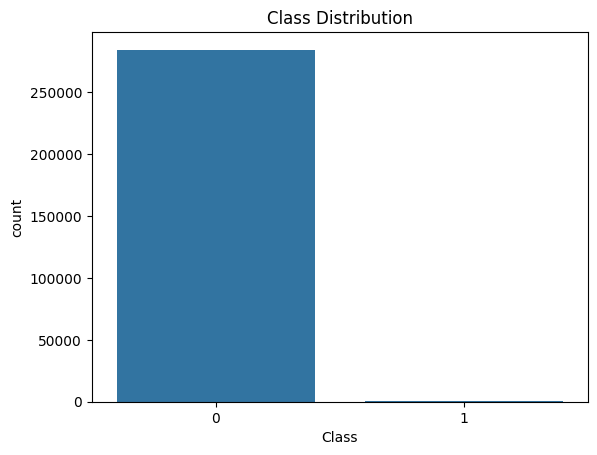

In [5]:
## No null data this info we derived from isnull.sum(). df.info gives info about data
## for visual representation using seaborne
# That would mean:

# comparing features (V1, V2, Amount, etc.) with Class
# like relationships or patterns
import seaborn as sns
sns.countplot(x='Class',data=df)
plt.title("Class Distribution")
plt.show()

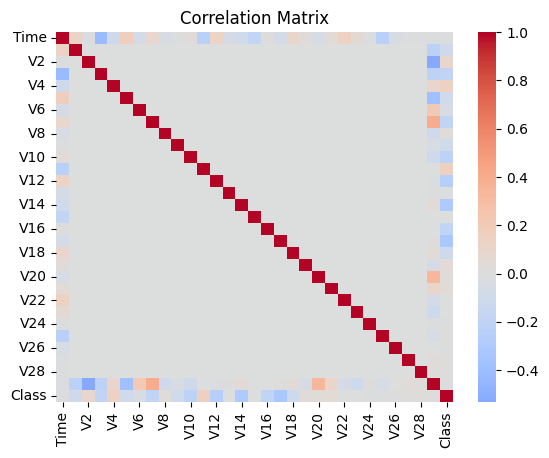

In [6]:
# Making correlation matrix blue very less correlation red very high , can remove blue features,
# but very less features alredy so not removing features
plt.Figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap='coolwarm',center=0)
plt.title("Correlation Matrix")
plt.show()

In [7]:
Fraud=df[df['Class']==1]
#df.describe will tell the mean ,median mode of the data
#time here tells time between two transactions.
#We need to scale the featues to [0,1] range because very high range otherwise 
#high values will be assigned as more weight
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
#To prevent data leakage otherwise model already know info regarding max of overall data
#Thats why we will split in test train and validation data then normalize calculate z scoreStandardization (Z-score normalization).

from sklearn.model_selection import train_test_split
# 80% trainval, take 20% test
x_trainval, x_test ,y_trainval, y_test=train_test_split(x,y,test_size=0.20,random_state=42)
#from trainval,take 20% as val =>overall val=16% of full data
x_train,x_val,y_train,y_val=train_test_split(
    x_trainval,y_trainval,test_size=0.20,random_state=42
)

In [9]:
# Now normalizing function using minmax formula

mu=x_train.mean(axis=0)
sigma=x_train.std(axis=0)
#not to make sigma zero we make add eps ,not to make denominator zero
eps=1e-15
x_train_s=(x_train - mu )/(sigma +eps )
x_val_s=(x_val -mu)/(sigma +eps )
x_test_s=(x_test -mu)/(sigma +eps )

In [10]:
# defining sigmoid function to make probabilities between +1 and 0
def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))
# loss function defition for logistic regression because logistic regression predicts probabilities
def logloss(y,p):
    p=np.clip(p,eps,1-eps)
    losses=-(y*np.log(p)+(1-y)*np.log(1-p))

    return np.mean(losses)

# Balanacing unbalanced data because fraud transactions are very less 
def compute_class_weights(y):
    #Blanced weights: w1=N/(2N1),w0=N/(2N0)
    n=len(y)
    n1=np.sum(y==1)
    n0=n-n1
    w1=n/(2*max(1.0,n1))
    w0=n/(2*max(1.0,n0))
    return float(w0),float(w1)

In [11]:
# Training
# we will train model with and without weighted loss to get an idea of what is actually happening without balancing and balaning
#unbalanced classes
def train_logreg_with_val(x_train,y_train,x_val,y_val,lr=0.01,epochs=200, weighted_loss=False):

    n,d=x_train.shape
    w=np.zeros(d)
    b=0.0
    # w=0, b=0 → z=0 → sigmoid=0.5 (same prediction initially)
    # error ≠ 0 → gradients update w, b
    # next iterations → predictions become different → model learns

    train_losses=[]
    val_losses=[]

    for epoch in range(1,epochs+1):
        # forward pass z function we will put in sigmoid function to get probability of the class
        z=x_train@w+b
        p=sigmoid(z)

        #gradients(traditional)
        error=(p-y_train) 

        if weighted_loss:
            w0, w1 =compute_class_weights(y_train)
        else:
            w0, w1=1.0,1.0

        ws= np.where(y_train==1,w1,w0)
        #if fraud y=1 then assign weight w1 else assign w0
        # w1 wight is of smaller class where w is small so w1 is more than w0
        #so in next step multipying error with respective weight to get weighted error 
        weighted_error=ws*error
        #Important samples (fraud) now contribute more to learning
        dw=  (x_train.T@weighted_error)/n
        db=np.mean(weighted_error)

        w-= lr*dw
        b-= lr*db

        train_loss=logloss(y_train,p)

        z_val=x_val@w +b
        p_val=sigmoid(z_val)
        val_loss=logloss(y_val,p_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if(epoch%5 == 0):
            print(f"epoch:{epoch:4d} train_logloss={train_loss:.6f} val_logloss={val_loss:.6f}")
            #whenever traing loss is less and validation loss is more then stop training the model further then 
            #model is overfitting stop the model

    return w,b,train_losses,val_losses

In [12]:
# Train model
w, b, train_losses, val_losses = train_logreg_with_val(
    x_train_s, y_train, x_val_s, y_val,
    lr=0.05, epochs=1000, weighted_loss=True
)

epoch:   5 train_logloss=0.675442 val_logloss=0.670817
epoch:  10 train_logloss=0.653079 val_logloss=0.648631
epoch:  15 train_logloss=0.631676 val_logloss=0.627418
epoch:  20 train_logloss=0.611284 val_logloss=0.607214
epoch:  25 train_logloss=0.591903 val_logloss=0.588017
epoch:  30 train_logloss=0.573509 val_logloss=0.569798
epoch:  35 train_logloss=0.556065 val_logloss=0.552520
epoch:  40 train_logloss=0.539529 val_logloss=0.536140
epoch:  45 train_logloss=0.523855 val_logloss=0.520613
epoch:  50 train_logloss=0.508997 val_logloss=0.505892
epoch:  55 train_logloss=0.494910 val_logloss=0.491933
epoch:  60 train_logloss=0.481548 val_logloss=0.478691
epoch:  65 train_logloss=0.468870 val_logloss=0.466124
epoch:  70 train_logloss=0.456835 val_logloss=0.454193
epoch:  75 train_logloss=0.445404 val_logloss=0.442859
epoch:  80 train_logloss=0.434541 val_logloss=0.432086
epoch:  85 train_logloss=0.424211 val_logloss=0.421841
epoch:  90 train_logloss=0.414384 val_logloss=0.412091
epoch:  95

In [13]:
# Prediction function
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

# Predict on test data
p_test = predict_proba(x_test_s, w, b)
y_pred = (p_test >= 0.99).astype(int)   # threshold can be adjusted 99 percent chance should be there that perspn is fraud

# Confusion Matrix
TP = int(np.sum((y_test == 1) & (y_pred == 1)))
TN = int(np.sum((y_test == 0) & (y_pred == 0)))
FP = int(np.sum((y_test == 0) & (y_pred == 1)))
FN = int(np.sum((y_test == 1) & (y_pred == 0)))

# Metrics
prec = TP / max(1, (TP + FP))
rec  = TP / max(1, (TP + FN))
f1   = 2 * prec * rec / max(1e-12, (prec + rec))

# Print results
print("Confusion Matrix:")
print("TP:", TP, "FP:", FP, "FN:", FN, "TN:", TN)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Confusion Matrix:
TP: 78 FP: 22 FN: 20 TN: 56842
Precision: 0.78
Recall: 0.7959183673469388
F1: 0.7878787878787878


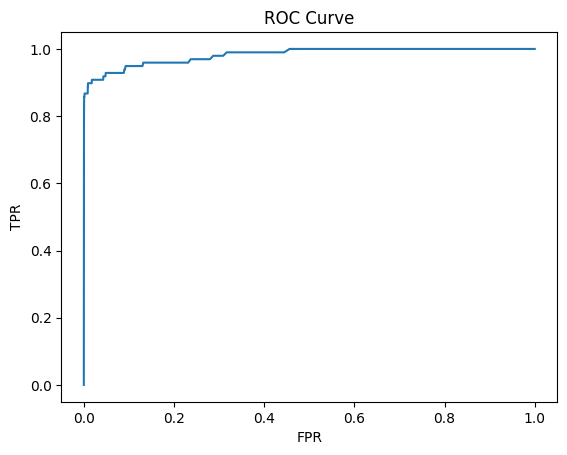

In [14]:
# ROC Curve function
def roc_curve(y_true, y_score, num_thresholds=500):
    thresholds = np.linspace(0.0, 1.0, num_thresholds)
    tpr_list = []
    fpr_list = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        TP = np.sum((y_true == 1) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))

        TPR = TP / max(1, (TP + FN))
        FPR = FP / max(1, (FP + TN))

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return np.array(fpr_list), np.array(tpr_list)

fpr, tpr = roc_curve(y_test, p_test)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [16]:
p_test_lr = predict_proba(x_test_s, w, b)
y_pred_lr = (p_test_lr >= 0.90).astype(int)

lr_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, p_test_lr)
}

In [17]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_s, y_train)

y_pred_dt = dt.predict(x_test_s)
y_score_dt = dt.predict_proba(x_test_s)[:, 1]

dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_score_dt)
}

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_s, y_train)

y_pred_rf = rf.predict(x_test_s)
y_score_rf = rf.predict_proba(x_test_s)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_score_rf)
}

In [19]:
knn = KNeighborsClassifier()
knn.fit(x_train_s, y_train)

y_pred_knn = knn.predict(x_test_s)
y_score_knn = knn.predict_proba(x_test_s)[:, 1]

knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1": f1_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_score_knn)
}

In [20]:
import pandas as pd

results = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "KNN": knn_metrics
}).T

print(results)

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.998157   0.480000  0.857143  0.615385  0.982230
Decision Tree        0.999192   0.770833  0.755102  0.762887  0.877358
Random Forest        0.999614   0.975000  0.795918  0.876404  0.962961
KNN                  0.999491   0.925926  0.765306  0.837989  0.928440


In [21]:
import joblib

# Save the trained weights and bias
model_data = {
    'w': w,
    'b': b,
    'mu': mu,      # mean from training
    'sigma': sigma # std from training (you used sigma + eps)
}

joblib.dump(model_data, 'fraud_model.pkl')
print("Model saved as 'fraud_model.pkl'")

Model saved as 'fraud_model.pkl'
